# **Import Libraries**

In [186]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.ensemble import AdaBoostClassifier

# **Load the Dataset**

In [156]:
df = pd.read_csv("/content/Predictive Maintenanccccccccce.csv")

In [157]:
df.head()

,date,device,Product ID,Type,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1/1/2015,S1F01085,M14860,M,24.95,35.45,1551.0,42.8,0,0
1,1/1/2015,S1F0166B,L47181,L,25.05,35.55,1408.0,46.3,3,0
2,1/1/2015,S1F01E6Y,L47182,L,24.95,35.35,1498.0,49.4,5,0
3,1/1/2015,S1F01JE0,L47183,L,25.05,35.45,1433.0,39.5,7,0
4,1/1/2015,S1F01R2B,L47184,L,25.05,35.55,1408.0,40.0,9,0


# **EDA**

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    10000 non-null  object 
 1   device                  10000 non-null  object 
 2   Product ID              10000 non-null  object 
 3   Type                    9994 non-null   object 
 4   Air temperature         9990 non-null   float64
 5   Process temperature     9991 non-null   float64
 6   Rotational speed [rpm]  9991 non-null   float64
 7   Torque [Nm]             10000 non-null  float64
 8   Tool wear [min]         10000 non-null  int64  
 9   Machine failure         10000 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 781.4+ KB


In [159]:
df.duplicated().sum()

np.int64(0)

In [160]:
df.describe()

,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,9990.000000,9991.000000,9991.000000,10000.000000,10000.000000,10000.000000
mean,26.855796,36.856156,1538.758383,39.986910,107.951000,0.033900
std,2.000598,1.483804,179.314068,9.968934,63.654147,0.180981
min,22.150000,32.550000,1168.000000,3.800000,0.000000,0.000000
25%,25.150000,35.650000,1423.000000,33.200000,53.000000,0.000000
50%,26.950000,36.950000,1503.000000,40.100000,108.000000,0.000000
75%,28.350000,37.950000,1612.000000,46.800000,162.000000,0.000000
max,31.350000,40.650000,2886.000000,76.600000,253.000000,1.000000


# **Check Nulls**

In [161]:
df.isnull().sum()

,0
date,0
device,0
Product ID,0
Type,6
Air temperature,10
Process temperature,9
Rotational speed [rpm],9
Torque [Nm],0
Tool wear [min],0
Machine failure,0


# **Visualization**

In [162]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


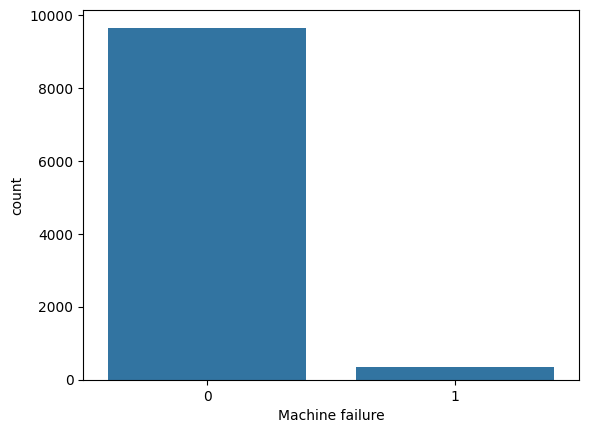

In [163]:
sns.countplot(x="Machine failure", data=df)
plt.show()

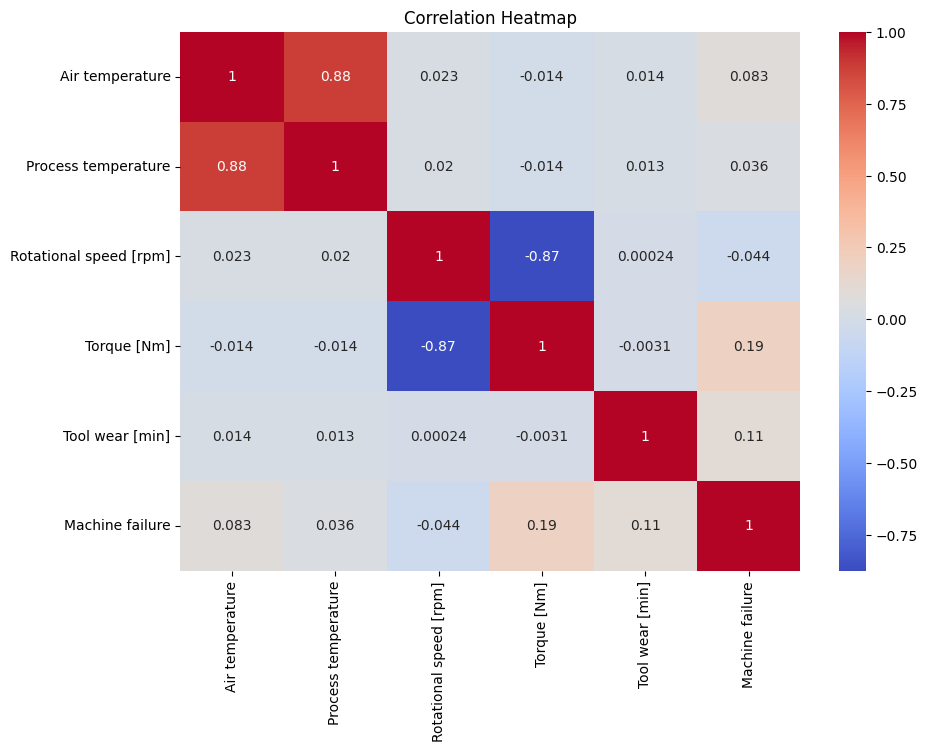

In [164]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# **PreProcessing**

In [165]:
numeric_cols = [
    "Air temperature",
    "Process temperature",
    "Rotational speed [rpm]"
]

imputer = SimpleImputer(strategy="median")

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [166]:
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])

In [167]:
df.isnull().sum()

,0
date,0
device,0
Product ID,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0


# **Split Into X & y**

In [168]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

X = X.drop(["date", "Product ID", "device"], axis=1)

X = pd.get_dummies(X, columns=["Type"], drop_first=True, dtype=int)

X.head()

,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,24.95,35.45,1551.0,42.8,0,0,1
1,25.05,35.55,1408.0,46.3,3,1,0
2,24.95,35.35,1498.0,49.4,5,1,0
3,25.05,35.45,1433.0,39.5,7,1,0
4,25.05,35.55,1408.0,40.0,9,1,0


In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Scaling**

In [170]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Models**

**LogisticRegression**

In [171]:

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [172]:
y_pred = model.predict(X_test)

In [173]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9675

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



**RandomForest**

In [174]:
rf_model = RandomForestClassifier(
    n_estimators=200,
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [175]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.56      0.68        68

    accuracy                           0.98      2000
   macro avg       0.93      0.78      0.84      2000
weighted avg       0.98      0.98      0.98      2000



**DecisionTree**

In [176]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [177]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9775
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.67      0.68      0.67        68

    accuracy                           0.98      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.98      0.98      0.98      2000



**svm**

In [178]:
svm_model = SVC()

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)


In [179]:
print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM
Accuracy: 0.9715
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1932
           1       0.87      0.19      0.31        68

    accuracy                           0.97      2000
   macro avg       0.92      0.60      0.65      2000
weighted avg       0.97      0.97      0.96      2000



**KNN**

In [180]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [181]:
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.974
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.83      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.90      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



**XGBoost**

In [182]:
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

In [183]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 0.989
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.72      0.82        68

    accuracy                           0.99      2000
   macro avg       0.97      0.86      0.91      2000
weighted avg       0.99      0.99      0.99      2000



 **AdaBoost**

In [187]:
ada_model = AdaBoostClassifier()
ada_model.fit(X_train, y_train)

y_pred = ada_model.predict(X_test)

In [188]:
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

AdaBoost Accuracy: 0.971
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.67      0.29      0.41        68

    accuracy                           0.97      2000
   macro avg       0.82      0.64      0.70      2000
weighted avg       0.97      0.97      0.97      2000



In [184]:
import gradio as gr

In [189]:
import gradio as gr
import pandas as pd

def predict_machine(
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear,
    machine_type
):

    input_data = pd.DataFrame({
        "Air temperature": [air_temperature],
        "Process temperature": [process_temperature],
        "Rotational speed [rpm]": [rotational_speed],
        "Torque [Nm]": [torque],
        "Tool wear [min]": [tool_wear],
        "Type_L": [1 if machine_type == "L" else 0],
        "Type_M": [1 if machine_type == "M" else 0]
    })

    # Same preprocessing used during training
    input_scaled = scaler.transform(input_data)

    # XGBoost prediction
    prediction = xgb_model.predict(input_scaled)[0]

    # Failure probability
    probability = xgb_model.predict_proba(input_scaled)[0][1]

    if prediction == 1:
        result = "🔴 MACHINE FAILURE RISK"
        message = "⚠️ Maintenance is recommended."
    else:
        result = "🟢 MACHINE OK"
        message = "✅ The machine is operating normally."

    return (
        f"{result}\n\n"
        f"Failure Probability : {probability * 100:.2f}%\n\n"
        f"{message}"
    )


# =========================================================
# Custom CSS
# =========================================================

custom_css = """

.gradio-container {
    max-width: 1000px !important;
    margin: auto !important;
}

.title {
    text-align: center;
}

.subtitle {
    text-align: center;
    color: #6b7280;
}

.result-box textarea {
    text-align: center;
    font-size: 20px !important;
    font-weight: bold;
}

"""


# =========================================================
# Gradio Interface
# =========================================================

with gr.Blocks(
    theme=gr.themes.Soft(),
    css=custom_css
) as interface:


    # -----------------------------------------------------
    # Header
    # -----------------------------------------------------

    gr.Markdown(
        """
        # ⚙️ Machine Failure Prediction

        ### Predictive Maintenance System
        """,
        elem_classes="title"
    )

    gr.Markdown(
        """
        Enter the machine parameters to predict
        whether the machine is likely to fail.
        """,
        elem_classes="subtitle"
    )


    # -----------------------------------------------------
    # Temperature
    # -----------------------------------------------------

    gr.Markdown("## 🌡️ Temperature")


    with gr.Row():

        air_temperature = gr.Number(
            label="Air Temperature (°C)",
            value=26.95
        )

        process_temperature = gr.Number(
            label="Process Temperature (°C)",
            value=36.95
        )


    # -----------------------------------------------------
    # Machine Performance
    # -----------------------------------------------------

    gr.Markdown("## ⚙️ Machine Performance")


    with gr.Row():

        rotational_speed = gr.Number(
            label="Rotational Speed (RPM)",
            value=1503
        )

        torque = gr.Number(
            label="Torque (Nm)",
            value=40
        )


    # -----------------------------------------------------
    # Tool Wear + Machine Type
    # -----------------------------------------------------

    with gr.Row():

        tool_wear = gr.Slider(
            minimum=0,
            maximum=253,
            step=1,
            value=108,
            label="Tool Wear (min)"
        )

        machine_type = gr.Dropdown(
            choices=["L", "M", "H"],
            value="M",
            label="Machine Type"
        )


    # -----------------------------------------------------
    # Prediction Button
    # -----------------------------------------------------

    predict_button = gr.Button(
        "🔍 Predict Machine Status",
        variant="primary",
        size="lg"
    )


    # -----------------------------------------------------
    # Result
    # -----------------------------------------------------

    gr.Markdown("## 📊 Prediction Result")


    result = gr.Textbox(
        label="Machine Status",
        lines=5,
        interactive=False,
        elem_classes="result-box"
    )


    # -----------------------------------------------------
    # Button Action
    # -----------------------------------------------------

    predict_button.click(
        fn=predict_machine,

        inputs=[
            air_temperature,
            process_temperature,
            rotational_speed,
            torque,
            tool_wear,
            machine_type
        ],

        outputs=result
    )


# =========================================================
# Launch
# =========================================================

interface.launch()

/tmp/ipykernel_4197/1702578040.py:79: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5765342b2cccf84e77.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
